In [1]:
%pip install wquantiles

In [45]:
%matplotlib inline

import pandas as pd
import numpy as np
from scipy.stats import trim_mean
from statsmodels import robust
import wquantiles
import seaborn as sns
import matplotlib.pylab as plt
from google.colab import files
uploaded = files.upload()

Saving airline_stats.csv to airline_stats.csv


# 1. Structured and Rectangular Data

Dibuku membedakan structured data menjadi beberapa bentuk. Untuk banyak pekerjaan data science, bentuk yang paling umum adalah **rectangular data**.

Dalam rectangular data:
- setiap **row** merupakan record/observation,
- setiap **column** merupakan feature/variable.



In [4]:

state = pd.read_csv('state.csv')
print(state.head(8))

         State  Population  Murder.Rate Abbreviation
0      Alabama     4779736          5.7           AL
1       Alaska      710231          5.6           AK
2      Arizona     6392017          4.7           AZ
3     Arkansas     2915918          5.6           AR
4   California    37253956          4.4           CA
5     Colorado     5029196          2.8           CO
6  Connecticut     3574097          2.4           CT
7     Delaware      897934          5.8           DE


# 2. Estimates of Location

**Location** digunakan untuk menggambarkan posisi pusat data.

## Mean

Untuk data \(x_1, x_2, ..., x_n\):

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i
$$

Mean mudah dihitung tetapi sensitif terhadap nilai ekstrem.

## Trimmed Mean

Trimmed mean membuang sejumlah nilai terkecil dan terbesar sebelum menghitung mean. Tujuannya adalah mengurangi pengaruh extreme values.

## Median

Median adalah nilai tengah setelah data diurutkan. Median lebih robust terhadap outlier dibandingkan mean.

## Weighted Mean

Jika setiap observasi mempunyai bobot \(w_i\):

$$
\bar{x}_w =
\frac{\sum_{i=1}^{n} w_i x_i}
{\sum_{i=1}^{n} w_i}
$$

Weighted mean berguna ketika observasi mempunyai tingkat kepentingan atau ukuran yang berbeda.

In [5]:
state['Population'].mean()

np.float64(6162876.3)

In [6]:
trim_mean(state['Population'], 0.1)

np.float64(4783697.125)

In [7]:
state['Population'].median()

4436369.5

In [8]:
np.average(state['Murder.Rate'], weights=state['Population'])

np.float64(4.445833981123393)

In [9]:
wquantiles.median(state['Murder.Rate'], weights=state['Population'])

np.float64(4.4)

### Interpretation

Perbedaan antara ordinary mean dan weighted mean menunjukkan bahwa cara kita memberikan bobot pada observasi dapat mengubah hasil.

Untuk murder rate, population dapat digunakan sebagai weight karena negara bagian dengan populasi besar mewakili jumlah penduduk yang jauh lebih besar daripada negara bagian dengan populasi kecil.

# 3. Estimates of Variability

**Variability** atau **dispersion** menunjukkan seberapa menyebar nilai data.

Beberapa ukuran yang dibahas:

### Deviation

Deviation suatu observasi terhadap mean:

$$
x_i - \bar{x}
$$

### Variance

Untuk sample:

$$
s^2 =
\frac{1}{n-1}
\sum_{i=1}^{n}(x_i-\bar{x})^2
$$

### Standard Deviation

$$
s = \sqrt{s^2}
$$

Standard deviation menggunakan satuan yang sama dengan data asli.

### IQR

Interquartile range:

$$
IQR = Q_3-Q_1
$$

### Median Absolute Deviation from the Median

MAD menggunakan jarak absolut setiap nilai terhadap median. Ukuran ini lebih robust terhadap outlier dibanding standard deviation.

In [10]:
print(state.head(8))

         State  Population  Murder.Rate Abbreviation
0      Alabama     4779736          5.7           AL
1       Alaska      710231          5.6           AK
2      Arizona     6392017          4.7           AZ
3     Arkansas     2915918          5.6           AR
4   California    37253956          4.4           CA
5     Colorado     5029196          2.8           CO
6  Connecticut     3574097          2.4           CT
7     Delaware      897934          5.8           DE


In [11]:
state['Population'].std()

6848235.347401142

In [12]:
state['Population'].quantile(0.75) - state['Population'].quantile(0.25)

np.float64(4847308.0)

In [13]:
robust.scale.mad(state['Population'])

np.float64(3849876.1459979336)

# 4. Percentiles and Boxplots

**Percentile** adalah nilai yang memiliki persentase tertentu dari data berada di bawahnya.

Contoh:
- 25th percentile = Q1,
- 50th percentile = median,
- 75th percentile = Q3.

Percentile berguna untuk melihat keseluruhan distribusi, termasuk bagian ekor/tails.

## Boxplot

Boxplot memberikan ringkasan visual distribusi:
- bagian bawah box = 25th percentile,
- garis di dalam box = median,
- bagian atas box = 75th percentile,
- whiskers menunjukkan rentang bulk data,
- titik di luar whiskers dapat muncul sebagai potential outliers.


In [14]:
state['Murder.Rate'].quantile([0.05, 0.25, 0.5, 0.75, 0.95])

,Murder.Rate
0.05,1.600
0.25,2.425
0.50,4.000
0.75,5.550
0.95,6.510


Text(0, 0.5, 'Population (millions)')

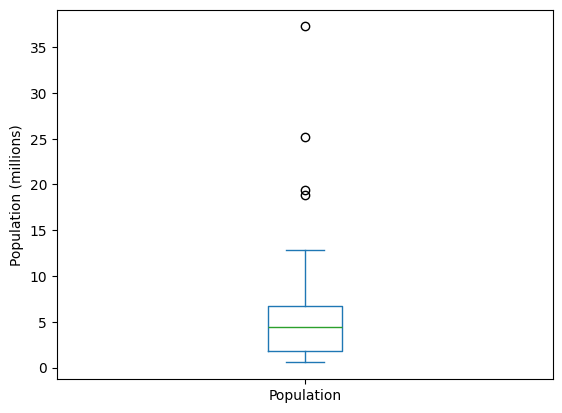

In [15]:
ax = (state['Population']/1_000_000).plot.box()
ax.set_ylabel('Population (millions)')

### Interpretasi

Pada data state, median population berada sekitar beberapa juta jiwa dan terdapat beberapa negara bagian dengan populasi jauh lebih tinggi. Boxplot membuat ketidaksimetrian dan nilai ekstrem tersebut mudah terlihat.

# 5. Frequency Tables and Histograms

**Frequency table** membagi rentang nilai menjadi interval atau **bins**, kemudian menghitung berapa observasi yang berada di setiap interval.

Histogram merupakan visualisasi frequency table dengan:
- nilai/bin pada sumbu x,
- count atau proportion pada sumbu y.

In [16]:
binnedPopulation = pd.cut(state['Population'], 10)
binnedPopulation.value_counts()

,count
Population,
"(526935.67, 4232659.0]",24
"(4232659.0, 7901692.0]",14
"(7901692.0, 11570725.0]",6
"(11570725.0, 15239758.0]",2
"(15239758.0, 18908791.0]",1
"(18908791.0, 22577824.0]",1
"(22577824.0, 26246857.0]",1
"(33584923.0, 37253956.0]",1
"(26246857.0, 29915890.0]",0


In [17]:
binnedPopulation.name = 'binnedPopulation'
df = pd.concat([state, binnedPopulation], axis=1)
df = df.sort_values(by='Population')

groups = []
for group, subset in df.groupby(by='binnedPopulation', observed=False):
    groups.append({
        'BinRange': group,
        'Count': len(subset),
        'States': ','.join(subset.Abbreviation)
    })
print(pd.DataFrame(groups))

                   BinRange  Count  \
0    (526935.67, 4232659.0]     24   
1    (4232659.0, 7901692.0]     14   
2   (7901692.0, 11570725.0]      6   
3  (11570725.0, 15239758.0]      2   
4  (15239758.0, 18908791.0]      1   
5  (18908791.0, 22577824.0]      1   
6  (22577824.0, 26246857.0]      1   
7  (26246857.0, 29915890.0]      0   
8  (29915890.0, 33584923.0]      0   
9  (33584923.0, 37253956.0]      1   

                                              States  
0  WY,VT,ND,AK,SD,DE,MT,RI,NH,ME,HI,ID,NE,WV,NM,N...  
1          KY,LA,SC,AL,CO,MN,WI,MD,MO,TN,AZ,IN,MA,WA  
2                                  VA,NJ,NC,GA,MI,OH  
3                                              PA,IL  
4                                                 FL  
5                                                 NY  
6                                                 TX  
7                                                     
8                                                     
9                              

Text(0.5, 0, 'Population (millions)')

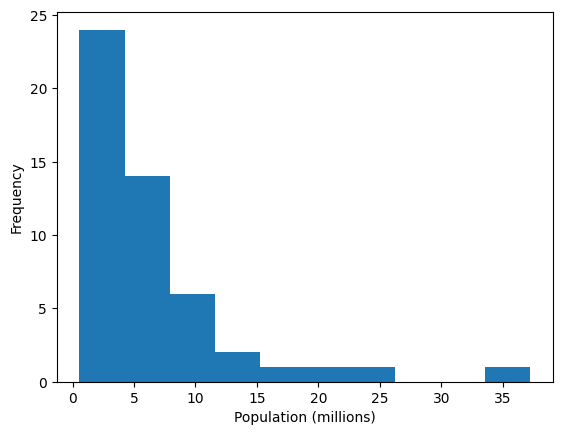

In [18]:
ax = (state['Population'] / 1_000_000).plot.hist()
ax.set_xlabel('Population (millions)')

### Interpretasi

Frequency table memberikan versi numerik dari histogram. Dengan melihat jumlah observasi di setiap bin, kita dapat memahami apakah data terkonsentrasi pada rentang tertentu atau memiliki ekor panjang.

# 6. Density Plots and KDE

Density plot merupakan representasi distribusi yang lebih halus dibandingkan histogram.

Kernel Density Estimate (KDE) dapat ditulis:

$$
\hat{f}(x) =
\frac{1}{nh}
\sum_{i=1}^{n}
K\left(\frac{x-x_i}{h}\right)
$$

di mana \(h\) merupakan bandwidth yang mengontrol tingkat smoothing.

Density plot berguna untuk melihat bentuk distribusi tanpa bergantung langsung pada batas-batas bin histogram.

Text(0.5, 0, 'Murder Rate (per 100,000)')

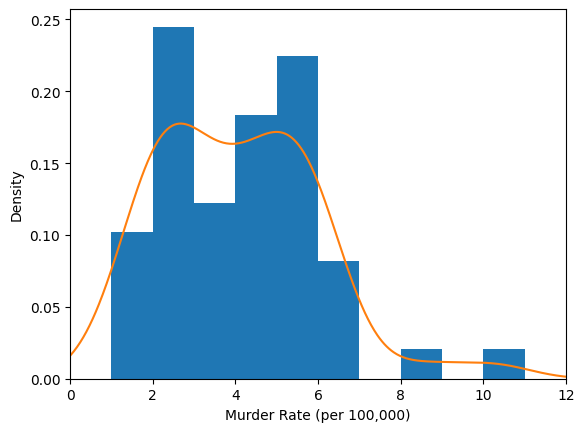

In [19]:
ax = state['Murder.Rate'].plot.hist(density=True, xlim=[0,12], bins=range(1,12))
state['Murder.Rate'].plot.density(ax=ax)
ax.set_xlabel('Murder Rate (per 100,000)')

### Interpretasi

Histogram menunjukkan frequency, sedangkan density plot menunjukkan bentuk distribusi sebagai kurva halus. Total area di bawah density curve bernilai 1.

# 7. Binary and Categorical Data

Untuk categorical data, jumlah mentah sering lebih mudah dipahami jika dikonversi menjadi **proportion** atau **percentage**.

Untuk binary variable:

$$
\text{Proportion} =
\frac{\text{jumlah kejadian}}
{\text{jumlah observasi}}
$$

Hasilnya dapat dikalikan 100 untuk memperoleh percentage.

In [23]:
dfw = pd.read_csv('dfw_airline.csv')
dfw

,Carrier,ATC,Weather,Security,Inbound
0,64263.16,84856.5,11235.42,343.15,118427.82


Text(0, 0.5, 'Count')

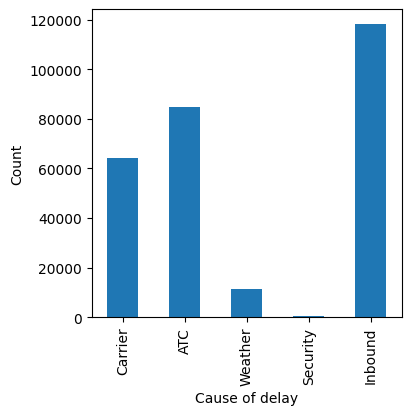

In [24]:
ax = dfw.transpose().plot.bar(figsize=(4, 4), legend=False)
ax.set_xlabel('Cause of delay')
ax.set_ylabel('Count')

# 8. Exploring Two or More Variables — Correlation

**Correlation coefficient** mengukur tingkat asosiasi antara dua paired variables.

Pearson correlation berada pada rentang:

$$
-1 \le r \le 1
$$

- nilai positif → kedua variabel cenderung bergerak searah,
- nilai negatif → cenderung bergerak berlawanan,
- mendekati 0 → asosiasi linear lemah.

Correlation bukan ukuran yang tepat untuk semua bentuk hubungan, terutama hubungan non-linear.

In [30]:
sp500_sym = pd.read_csv('sp500_sectors.csv')
sp500_px = pd.read_csv('sp500_data.csv', index_col=0)

In [31]:
telecomSymbols = sp500_sym[sp500_sym['sector'] == 'telecommunications_services']['symbol']
telecom = sp500_px.loc[sp500_px.index >= '2012-07-01', telecomSymbols]
telecom.corr()

,T,CTL,FTR,VZ,LVLT
T,1.000000,0.474683,0.327767,0.677612,0.278626
CTL,0.474683,1.000000,0.419757,0.416604,0.286665
FTR,0.327767,0.419757,1.000000,0.287386,0.260068
VZ,0.677612,0.416604,0.287386,1.000000,0.242199
LVLT,0.278626,0.286665,0.260068,0.242199,1.000000


## Correlation Matrix dan Heatmap

Digunakan ETF untuk menunjukkan correlation matrix dalam bentuk visual. Heatmap membantu ketika jumlah variabel cukup banyak sehingga tabel correlation sulit dibaca.

<Axes: >

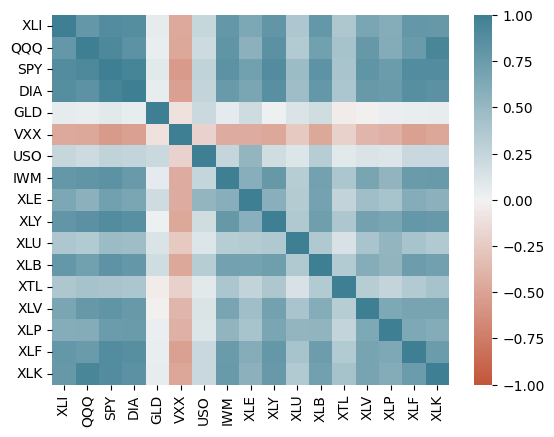

In [32]:
etfs = sp500_px.loc[sp500_px.index > '2012-07-01',
                    sp500_sym[sp500_sym['sector'] == 'etf']['symbol']]
sns.heatmap(etfs.corr(), vmin=-1, vmax=1,
            cmap=sns.diverging_palette(20, 220, as_cmap=True))

### Interpretasi

Diagonal correlation matrix selalu bernilai 1 karena setiap variabel berkorelasi sempurna dengan dirinya sendiri. Pasangan dengan correlation positif tinggi cenderung bergerak searah.

# 9. Scatterplots

Scatterplot digunakan untuk melihat hubungan antara dua variabel numerik.

Setiap titik merepresentasikan satu observasi.

Scatterplot penting karena correlation coefficient hanya merangkum hubungan secara numerik, sedangkan scatterplot memungkinkan kita melihat pola, outlier, dan bentuk hubungan secara visual.

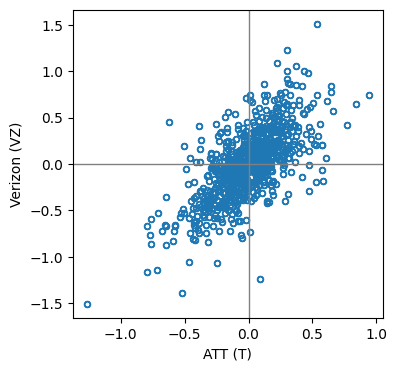

In [33]:
ax = telecom.plot.scatter(x='T', y='VZ', figsize=(4, 4), marker='$\u25EF$')
ax.set_xlabel('ATT (T)')
ax.set_ylabel('Verizon (VZ)')
ax.axhline(0, color='grey', lw=1)
ax.axvline(0, color='grey', lw=1)

### Interpretasi

Scatterplot memperlihatkan kecenderungan hubungan positif antara return ATT dan Verizon. Titik banyak terkumpul di sekitar nol, dengan kecenderungan kedua saham bergerak ke arah yang sama pada banyak hari.

# 10. Hexagonal Binning and Contours

Jika jumlah data sangat besar, scatterplot dapat menjadi sulit dibaca karena terlalu banyak titik yang bertumpuk.

**Hexagonal binning** mengelompokkan titik ke dalam sel berbentuk hexagon dan menampilkan kepadatan data.

**Contour plot / density plot 2D** juga dapat digunakan untuk melihat kepadatan dua variabel numerik.

In [36]:
kc_tax = pd.read_csv('kc_tax.csv.gz')
kc_tax0 = kc_tax.loc[(kc_tax.TaxAssessedValue < 750000) &
                     (kc_tax.SqFtTotLiving > 100) &
                     (kc_tax.SqFtTotLiving < 3500), :]

Text(0, 0.5, 'Tax Assessed Value')

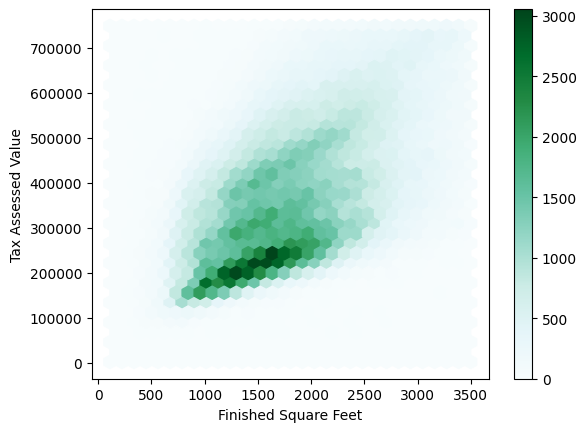

In [37]:
ax = kc_tax0.plot.hexbin(x='SqFtTotLiving', y='TaxAssessedValue',
                         gridsize=30, sharex=False)
ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax Assessed Value')

Text(0, 0.5, 'Tax Assessed Value')

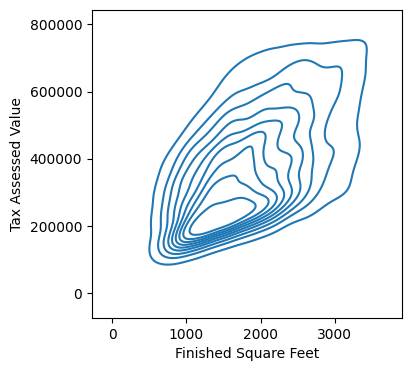

In [38]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.kdeplot(data=kc_tax0.sample(10000), x='SqFtTotLiving',
            y='TaxAssessedValue', ax=ax)
ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax Assessed Value')

### Interpretasi

Hexbin memperlihatkan area yang memiliki konsentrasi observasi tinggi tanpa menampilkan seluruh titik satu per satu. KDE dua dimensi memberikan representasi kepadatan yang lebih halus.

# 11. Two Categorical Variables — Contingency Tables

**Contingency table** merangkum jumlah observasi berdasarkan dua categorical variables.

- `grade` = grade personal loan,
- `status` = status loan.

Pivot table dapat digunakan untuk memperoleh count dan persentase.

In [41]:
lc_loans = pd.read_csv('lc_loans.csv')
lc_loans

,status,grade
0,Fully Paid,B
1,Charged Off,C
2,Fully Paid,C
3,Fully Paid,C
4,Current,B
...,...,...
450956,Current,D
450957,Current,D
450958,Current,D
450959,Current,D


In [42]:
crosstab = lc_loans.pivot_table(index='grade', columns='status',
                                aggfunc=lambda x: len(x), margins=True)
crosstab

status,Charged Off,Current,Fully Paid,Late,All
grade,,,,,
A,1562,50051,20408,469,72490
B,5302,93852,31160,2056,132370
C,6023,88928,23147,2777,120875
D,5007,53281,13681,2308,74277
E,2842,24639,5949,1374,34804
F,1526,8444,2328,606,12904
G,409,1990,643,199,3241
All,22671,321185,97316,9789,450961


In [43]:
df = crosstab.loc['A':'G',:].copy()
df.loc[:,'Charged Off':'Late'] = df.loc[:,'Charged Off':'Late'].div(df['All'],
                                                                     axis=0)
df['All'] = df['All'] / sum(df['All'])
perc_crosstab = df
perc_crosstab

/tmp/ipykernel_874/1453298063.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.0215478  0.04005439 0.04982834 0.06740983 0.08165728 0.1182579
 0.12619562]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:,'Charged Off':'Late'] = df.loc[:,'Charged Off':'Late'].div(df['All'],
/tmp/ipykernel_874/1453298063.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.69045386 0.70901262 0.73570217 0.71732838 0.70793587 0.65437074
 0.61400802]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:,'Charged Off':'Late'] = df.loc[:,'Charged Off':'Late'].div(df['All'],
/tmp/ipykernel_874/1453298063.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.28152849 0.23540077 0.19149535 0.18418

status,Charged Off,Current,Fully Paid,Late,All
grade,,,,,
A,0.021548,0.690454,0.281528,0.006470,0.160746
B,0.040054,0.709013,0.235401,0.015532,0.293529
C,0.049828,0.735702,0.191495,0.022974,0.268039
D,0.067410,0.717328,0.184189,0.031073,0.164708
E,0.081657,0.707936,0.170929,0.039478,0.077177
F,0.118258,0.654371,0.180409,0.046962,0.028614
G,0.126196,0.614008,0.198396,0.061401,0.007187


### Interpretasi

Contingency table memungkinkan kita melihat pola status loan pada setiap grade. Persentase baris membantu membandingkan komposisi status antar-grade, bukan hanya jumlah absolut.

# 12. Categorical and Numeric Data

Ketika satu variabel bersifat categorical dan variabel lainnya numeric, boxplot dapat digunakan untuk membandingkan distribusi numeric variable antar kategori.

Violin plot menambahkan informasi mengenai bentuk density distribusi.

In [46]:
airline_stats = pd.read_csv('airline_stats.csv')
airline_stats.head()

,pct_carrier_delay,pct_atc_delay,pct_weather_delay,airline
0,8.153226,1.971774,0.762097,American
1,5.959924,3.706107,1.585878,American
2,7.157270,2.706231,2.026706,American
3,12.100000,11.033333,0.000000,American
4,7.333333,3.365591,1.774194,American


Text(0.5, 0.98, '')

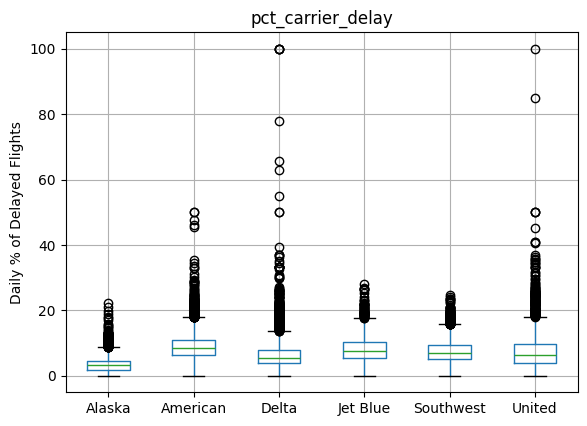

In [52]:
ax = airline_stats.boxplot(by='airline', column='pct_carrier_delay')
ax.set_xlabel('')
ax.set_ylabel('Daily % of Delayed Flights')
plt.suptitle('')

In [ ]:
ax = sns.violinplot(airline_stats.airline, airline_stats.pct_carrier_delay,
                    inner='quartile', color='white')
ax.set_xlabel('')
ax.set_ylabel('Daily % of Delayed Flights')

### Interpretasi

Boxplot memperlihatkan median, quartile, dan outlier. Violin plot menambahkan informasi tentang bentuk density distribution sehingga beberapa pola distribusi yang tidak jelas pada boxplot dapat terlihat.

# 13. Multiple Variables

EDA tidak hanya dilakukan pada satu variabel.

Secara umum:

- **Univariate** → satu variabel.
- **Bivariate** → dua variabel.
- **Multivariate** → lebih dari dua variabel.

Pemilihan visualisasi bergantung pada tipe variabel:

| Kombinasi | Contoh |
|---|---|
| Numeric × Numeric | Scatterplot, hexbin |
| Categorical × Categorical | Contingency table |
| Categorical × Numeric | Boxplot, violin plot |

Tujuan akhirnya adalah memperoleh pemahaman mengenai struktur, distribusi, outlier, dan hubungan dalam dataset sebelum melakukan modeling.

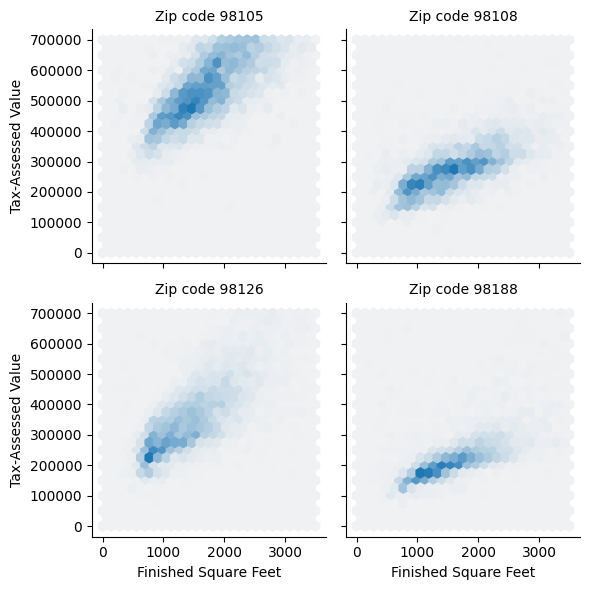

In [54]:
zip_codes = [98188, 98105, 98108, 98126]
kc_tax_zip = kc_tax0.loc[kc_tax0.ZipCode.isin(zip_codes),:]
kc_tax_zip

def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.hexbin(x, y, gridsize=25, cmap=cmap, **kwargs)

g = sns.FacetGrid(kc_tax_zip, col='ZipCode', col_wrap=2)
g.map(hexbin, 'SqFtTotLiving', 'TaxAssessedValue',
      extent=[0, 3500, 0, 700000])
g.set_axis_labels('Finished Square Feet', 'Tax-Assessed Value')
g.set_titles('Zip code {col_name:.0f}')

### Interpretasi

Facet memungkinkan hubungan dua variabel numerik dilihat secara terpisah berdasarkan kategori tambahan, yaitu zip code. Ini membantu mengungkap perbedaan distribusi yang dapat tersembunyi ketika seluruh data digabungkan.